# Modelo Base SARSA con Gymnasium


**Objetivo:** Crear una línea base rápida (solo con `SPY`) para validar la estrategia antes de pasar a Deep Learning.
**Origen de Datos:** Usaremos la lógica de descarga y limpieza definida en el *Notebook_Descriptivo_Dataset.ipynb*.

-----

## 1. Configuración del Entorno

Primero, nos aseguramos de tener las librerías que usamos en el notebook más las de RL:

```bash
pip install gymnasium numpy pandas yfinance matplotlib seaborn
```

-----

## 2. Código Completo SARSA

En este cuaderno implementamos nuestro primer agente de aprendizaje por refuerzo con SARSA sobre un único activo (SPY). Cargamos los datos históricos, calculamos indicadores sencillos (SMA200 y RSI), discretizamos el estado en pocas categorías y definimos un espacio de acciones muy simple (comprar, vender o mantener). Entrenamos el agente con SARSA tabular, lo comparamos frente a una estrategia buy & hold y visualizamos tanto la evolución de la cartera como la política aprendida en forma de mapa de calor.

[*********************100%***********************]  1 of 1 completed

Descargando datos...
Datos Train: 2860 | Datos Test: 715
Entrenando agente...



C:\Users\34665\AppData\Local\Temp\ipykernel_635852\2684526801.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').dropna()


Evaluando en datos de Test...


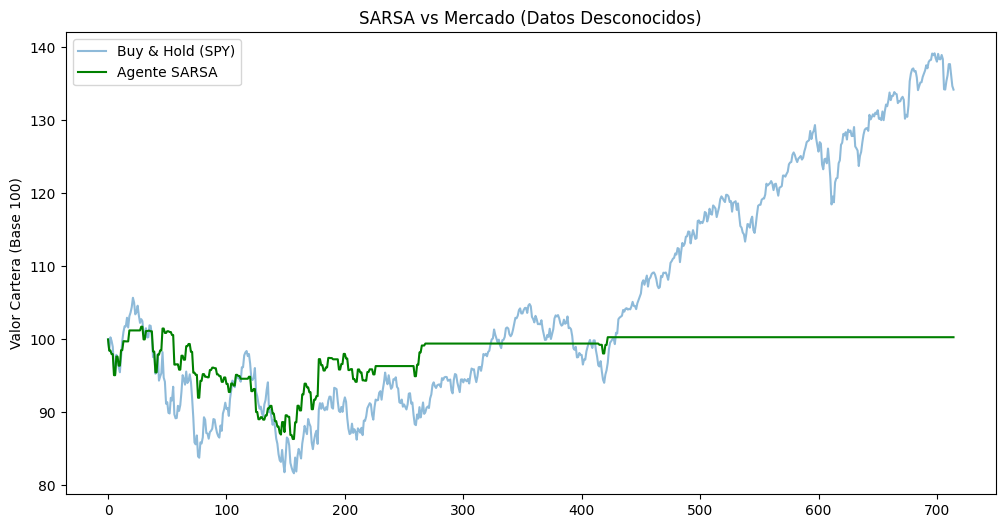

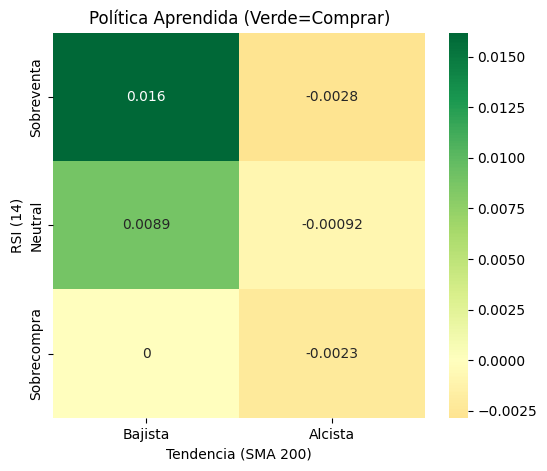

In [3]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. INGENIERÍA DE DATOS
# ==========================================
def get_data_and_preprocess():
    """Descarga SPY, limpia y genera estados discretos."""
    print("Descargando datos...")
    df = yf.download("SPY", start="2010-01-01", end="2025-01-01", auto_adjust=False)
    
    # Aplanar índice si es necesario
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Limpieza básica
    df = df.fillna(method='ffill').dropna()

    # Indicadores Técnicos (Manual implementation to avoid pandas-ta dependency)
    # SMA 200
    df['SMA_200'] = df['Close'].rolling(window=200).mean()
    
    # RSI 14
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    # Use exponential moving average for RSI (Wilder's smoothing)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # Recompensa: Retorno Logarítmico (para normalizar volatilidad)
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

    # Eliminar NaNs generados por indicadores
    df = df.dropna().reset_index(drop=True)

    # --- DISCRETIZACIÓN (Convertir números a Estados para la Q-Table) ---
    
    # Estado 1: Tendencia (0: Bajista, 1: Alcista)
    df['State_Trend'] = np.where(df['Close'] > df['SMA_200'], 1, 0)

    # Estado 2: RSI (0: Sobreventa, 1: Neutral, 2: Sobrecompra)
    conditions = [(df['RSI'] < 30), (df['RSI'] > 70)]
    choices = [0, 2]
    df['State_RSI'] = np.select(conditions, choices, default=1)
    
    return df

# ==========================================
# 2. ENTORNO GYMNASIUM (La Simulación)
# ==========================================
class SarsaTradingEnv(gym.Env):
    def __init__(self, df):
        super(SarsaTradingEnv, self).__init__()
        self.df = df
        
        # Acciones: 0 = Cash (Fuera), 1 = Long (Dentro)
        self.action_space = spaces.Discrete(2)
        
        # Estados: 12 combinaciones posibles (2 Tendencias * 3 RSIs * 2 Posiciones)
        self.observation_space = spaces.Discrete(12)
        
        self.current_step = 0
        self.in_position = 0 # Empezamos en Cash

    def _get_state_id(self):
        # Convierte los factores en un índice único para la tabla
        row = self.df.iloc[self.current_step]
        trend = int(row['State_Trend'])
        rsi = int(row['State_RSI'])
        pos = self.in_position
        
        # Fórmula de mapeo único
        return (trend * 6) + (rsi * 2) + pos

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.in_position = 0 
        return self._get_state_id(), {}

    def step(self, action):
        # 1. Ejecutar decisión
        self.in_position = action 
        
        # 2. Avanzar tiempo
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1
        
        # 3. Recompensa: Si estamos dentro, ganamos/perdemos lo que haga el mercado
        market_return = self.df.iloc[self.current_step]['Log_Return']
        reward = market_return if self.in_position == 1 else 0
        
        # 4. Nuevo estado
        next_state = self._get_state_id()
        
        return next_state, reward, terminated, False, {}

# ==========================================
# 3. ENTRENAMIENTO Y EVALUACIÓN
# ==========================================
def train_sarsa():
    # Cargar datos
    df = get_data_and_preprocess()
    
    # Separar Train (2010-2020) y Test (2021-2025) aprox
    split_idx = int(len(df) * 0.8)
    df_train = df.iloc[:split_idx].reset_index(drop=True)
    df_test = df.iloc[split_idx:].reset_index(drop=True)
    
    print(f"Datos Train: {len(df_train)} | Datos Test: {len(df_test)}")

    # Configuración
    env = SarsaTradingEnv(df_train)
    Q_table = np.zeros((env.observation_space.n, env.action_space.n))
    
    alpha = 0.1       # Tasa de aprendizaje
    gamma = 0.95      # Visión a futuro
    epsilon = 1.0     # Exploración
    epsilon_decay = 0.995
    min_epsilon = 0.01

    # --- BUCLE DE ENTRENAMIENTO ---
    print("Entrenando agente...")
    for episode in range(500):
        state, _ = env.reset()
        
        # Epsilon-Greedy inicial
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_table[state])
            
        done = False
        while not done:
            next_state, reward, done, _, _ = env.step(action)
            
            # SARSA necesita la siguiente acción (A') para actualizar
            if np.random.rand() < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = np.argmax(Q_table[next_state])
            
            # Actualización de la Tabla Q
            target = reward + gamma * Q_table[next_state, next_action]
            Q_table[state, action] += alpha * (target - Q_table[state, action])
            
            state = next_state
            action = next_action
        
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

    return Q_table, df_test

def evaluate_and_plot(Q_table, df_test):
    print("Evaluando en datos de Test...")
    env = SarsaTradingEnv(df_test)
    state, _ = env.reset()
    done = False
    
    strategy_returns = [0]
    market_returns = [0]
    
    # Backtesting (Solo explotación, sin explorar)
    while not done:
        action = np.argmax(Q_table[state])
        next_state, reward, done, _, _ = env.step(action)
        
        # Retorno del mercado (para comparar)
        market_ret = env.df.iloc[env.current_step]['Log_Return']
        market_returns.append(market_returns[-1] + market_ret)
        
        # Retorno de la estrategia
        strategy_returns.append(strategy_returns[-1] + reward)
        
        state = next_state

    # 1. Gráfica de Rendimiento
    plt.figure(figsize=(12, 6))
    plt.plot(np.exp(market_returns) * 100, label='Buy & Hold (SPY)', alpha=0.5)
    plt.plot(np.exp(strategy_returns) * 100, label='Agente SARSA', color='green')
    plt.title('SARSA vs Mercado (Datos Desconocidos)')
    plt.ylabel('Valor Cartera (Base 100)')
    plt.legend()
    plt.show()

    # 2. Mapa de Calor (El "Cerebro" del agente)
    # Eje Y: RSI (0=Bajo, 1=Medio, 2=Alto) | Eje X: Tendencia (0=Baja, 1=Alta)
    # Color: Verde = Comprar, Rojo = Vender
    
    # Transformamos la tabla Q a una matriz 3x2 de "Ganas de Comprar"
    # Valor = Q(Comprar) - Q(Vender)
    policy_matrix = np.zeros((3, 2)) 
    for rsi in range(3):
        for trend in range(2):
            # Estado base (asumiendo que estamos en Cash)
            state_id = (trend * 6) + (rsi * 2) + 0 
            policy_matrix[rsi, trend] = Q_table[state_id, 1] - Q_table[state_id, 0]

    plt.figure(figsize=(6, 5))
    sns.heatmap(policy_matrix, annot=True, cmap='RdYlGn', center=0,
                xticklabels=['Bajista', 'Alcista'], 
                yticklabels=['Sobreventa', 'Neutral', 'Sobrecompra'])
    plt.title('Política Aprendida (Verde=Comprar)')
    plt.xlabel('Tendencia (SMA 200)')
    plt.ylabel('RSI (14)')
    plt.show()

# --- EJECUTAR ---
if __name__ == "__main__":
    trained_q, test_data = train_sarsa()
    evaluate_and_plot(trained_q, test_data)